In [ ]:
#Bank Term Deposit Subscription Prediction

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
df = pd.read_csv('bank-full.csv',sep=';',encoding='latin1')

In [ ]:
print('rows x cols = ', df.shape)

rows x cols =  (45211, 17)


In [ ]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [ ]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [ ]:
X = df.drop(columns='y')
y = df['y'].map({'no':0, 'yes':1})

In [ ]:
X.shape , y.shape

((45211, 16), (45211,))

In [ ]:
y.value_counts()

,count
y,
0,39922
1,5289


In [ ]:
y.value_counts(normalize=True) * 100

,proportion
y,
0,88.30152
1,11.69848


In [ ]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=np.number).columns

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)

Categorical columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

Numerical columns:
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [ ]:
X["job"].value_counts(normalize=True) * 100

,proportion
job,
blue-collar,21.525735
management,20.919688
technician,16.803433
admin.,11.437482
services,9.188029
retired,5.007631
self-employed,3.492513
entrepreneur,3.289023
unemployed,2.882042


In [ ]:
#Numerical Destribution

In [ ]:
X[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


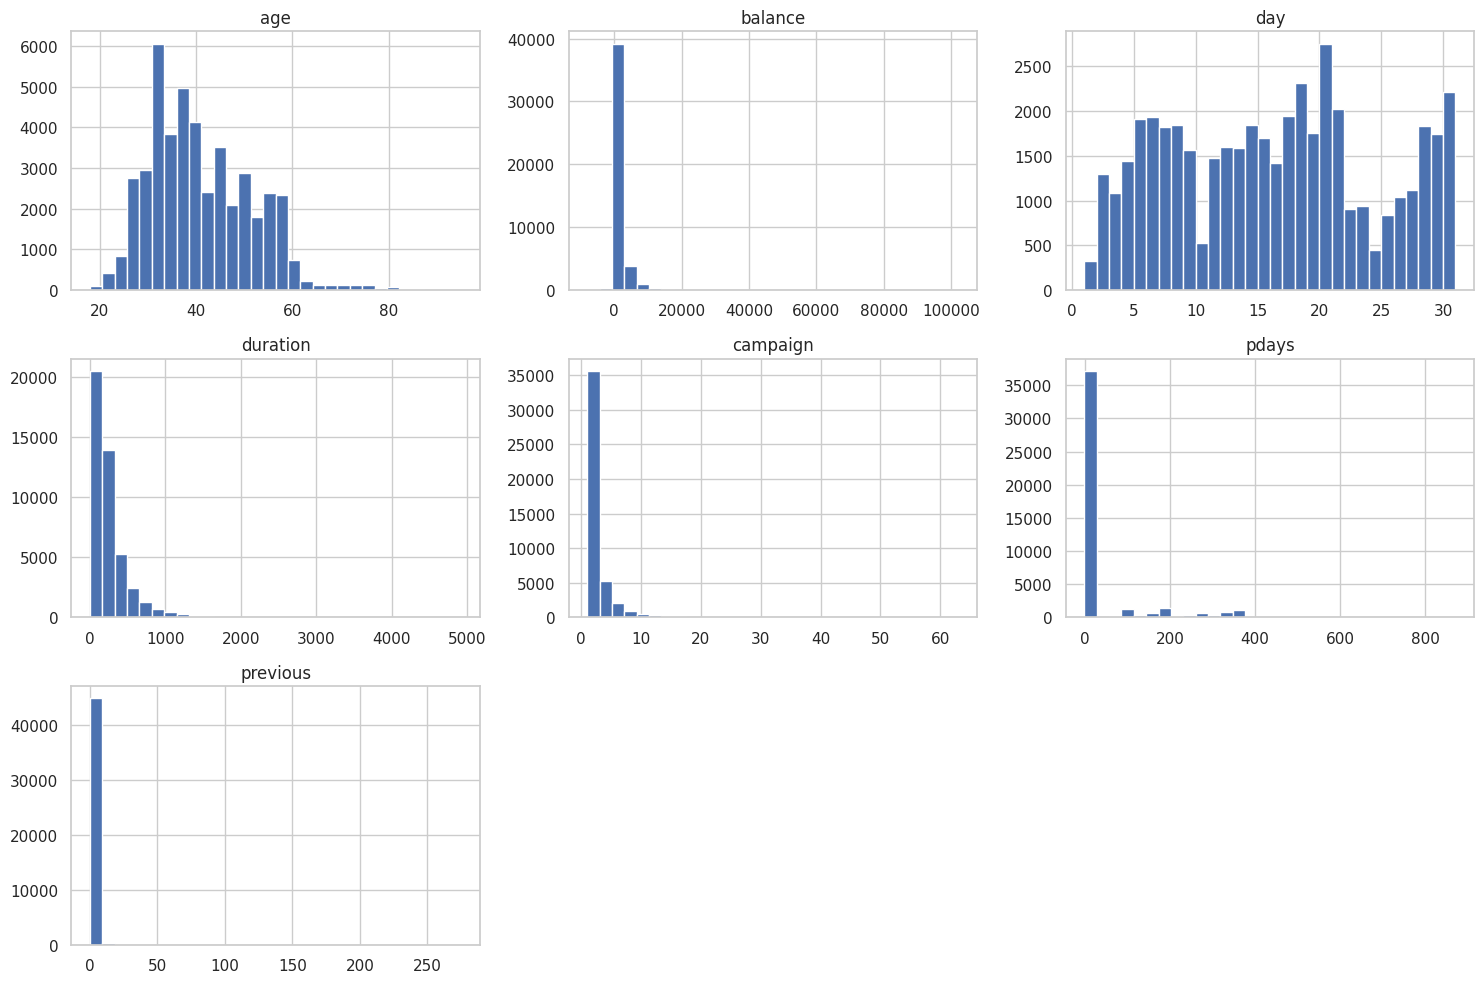

In [ ]:
X[num_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

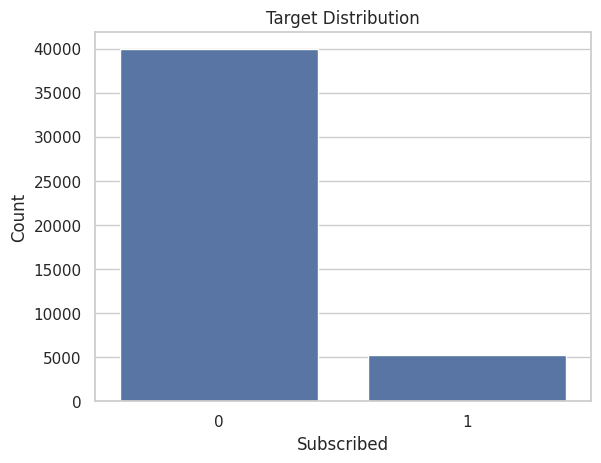

In [ ]:
sns.countplot(x=y)

plt.title("Target Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.show()

In [ ]:
categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(X[col].unique())


job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital
['married' 'single' 'divorced']

education
['tertiary' 'secondary' 'unknown' 'primary']

default
['no' 'yes']

housing
['yes' 'no']

loan
['no' 'yes']

contact
['unknown' 'cellular' 'telephone']

month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome
['unknown' 'failure' 'other' 'success']


In [ ]:
binary_cols = [
    "default",
    "housing",
    "loan"
]

In [ ]:
binary_map = {
    "no": 0,
    "yes": 1
}

for col in binary_cols:
    X[col] = X[col].map(binary_map)

In [ ]:
one_hot_cols = [
    "job",
    "marital",
    "education",
    "contact",
    "month",
    "poutcome"
]

X = pd.get_dummies(
    X,
    columns=one_hot_cols,
    dtype=int
)

In [ ]:
X = X.drop(columns="duration")

In [ ]:
X.shape

(45211, 47)

In [ ]:
X.head(10)

,age,default,balance,housing,loan,day,campaign,pdays,previous,job_admin.,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
1,44,0,29,1,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
2,33,0,2,1,1,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
3,47,0,1506,1,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
4,33,0,1,0,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
5,35,0,231,1,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
6,28,0,447,1,1,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
7,42,1,2,1,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
8,58,0,121,1,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1
9,43,0,593,1,0,5,1,-1,0,0,...,0,0,1,0,0,0,0,0,0,1


In [ ]:
X = df.drop(columns=["y", "duration"])

In [ ]:
exclude_cols = [
    "contact",
    "day",
    "month",
    "duration",
    "campaign"
]

X = df.drop(columns=["y"] + exclude_cols)

y = df["y"].map({
    "no": 0,
    "yes": 1
})

In [ ]:
print(X.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'pdays', 'previous', 'poutcome']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [ ]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']
Numerical: ['age', 'balance', 'pdays', 'previous']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_cols
        )
    ]
)

In [ ]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [ ]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan',
       'poutcome'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8935087913303107
Precision: 0.6819923371647509
Recall   : 0.16824196597353497
F1       : 0.2699014404852161
ROC-AUC  : 0.7202434739995714


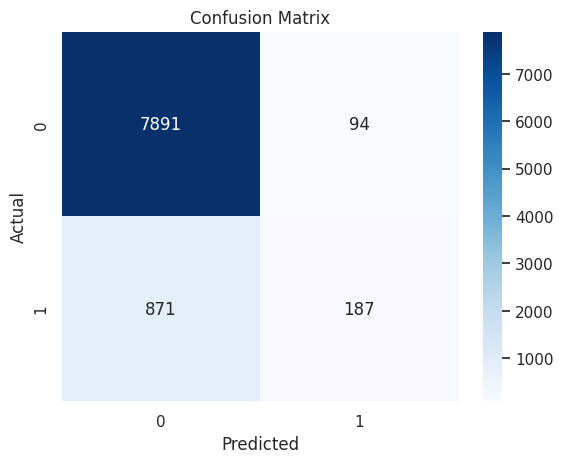

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()